For more information and Dataset check **[Here](https://www.kaggle.com/datasets/uciml/german-credit/data)**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings('ignore')

## Data prep and EDA

In [2]:
data = pd.read_csv(r"C:\Users\AFRAA\OneDrive\Desktop\Datasets\german_credit_data.csv")
data

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [4]:
data.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [5]:
data.describe(include='O')

,Sex,Housing,Saving accounts,Checking account,Purpose
count,1000,1000,817,606,1000
unique,2,3,4,3,8
top,male,own,little,little,car
freq,690,713,603,274,337


## Data Preprocessing

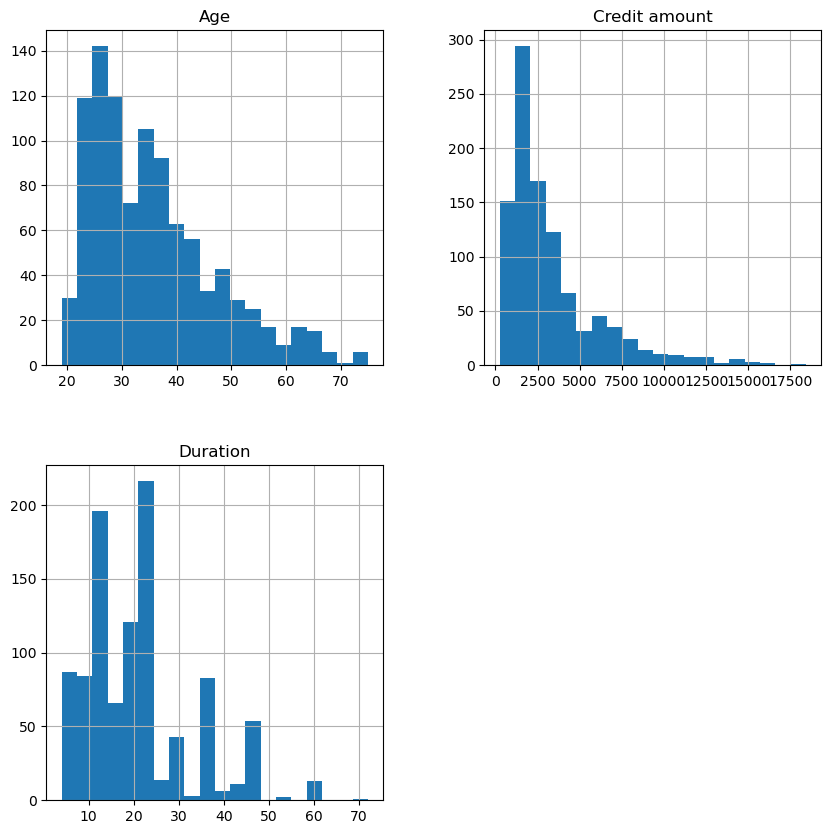

In [6]:
numerical_col = data.select_dtypes(include=['int64', 'float64']).columns
numerical_col = numerical_col.drop(['Unnamed: 0', 'Job'])
data[numerical_col].hist(bins = 20, sharex =False, figsize=(10, 10))
plt.show()

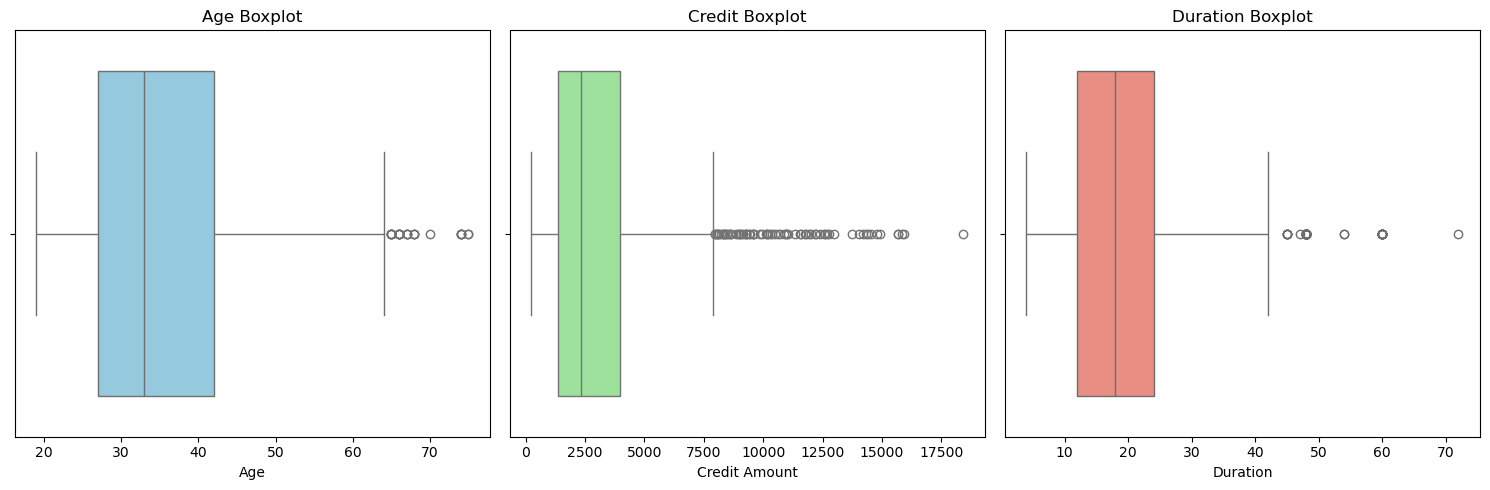

In [7]:
import seaborn as sns

plt.figure(figsize=(15, 5))

# Subplot 1: Age by Target
plt.subplot(1, 3, 1)
sns.boxplot(x='Age', data=data, orient='h', color='skyblue')
plt.title('Age Boxplot')
plt.xlabel('Age')


# Subplot 2: Credit Amount by Target
plt.subplot(1, 3, 2)
sns.boxplot(x='Credit amount', data=data, orient='h', color='lightgreen')
plt.title('Credit Boxplot')
plt.xlabel('Credit Amount')


# Subplot 3: Duration by Target
plt.subplot(1, 3, 3)
sns.boxplot(x='Duration', data=data, orient='h', color='salmon')
plt.title('Duration Boxplot')
plt.xlabel('Duration')


plt.tight_layout()
plt.show()

In [8]:
Age_Q1 = data['Age'].quantile(0.25)
Age_Q3 = data['Age'].quantile(0.75)
Age_IQR = Age_Q3 -  Age_Q1

Age_outlier = data[(data['Age'] < (Age_Q1 - 1.5 * Age_IQR)) | (data['Age'] >( Age_Q3 + 1.5 * Age_IQR))]

data.loc[(data['Age'] < (Age_Q1 - 1.5 * Age_IQR)) | (data['Age'] > ( Age_Q3 + 1.5 * Age_IQR)), 'Age'] = np.nan # miss outliers to handle them

In [9]:
Credit_Q1 = data['Credit amount'].quantile(0.25)
Credit_Q3 = data['Credit amount'].quantile(0.75)
Credit_IQR = Credit_Q3 -  Credit_Q1

Credit_outlier = data[(data['Credit amount'] < (Credit_Q1 - 1.5 * Credit_IQR)) | (data['Credit amount'] > ( Credit_Q3 + 1.5 * Credit_IQR))]

data.loc[(data['Credit amount'] < (Credit_Q1 - 1.5 * Credit_IQR)) | (data['Credit amount'] > ( Credit_Q3 + 1.5 * Credit_IQR)), 'Credit amount'] = np.nan

In [10]:
Duration_Q1 = data['Duration'].quantile(0.25)
Duration_Q3 = data['Duration'].quantile(0.75)
Duration_IQR = Duration_Q3 -  Duration_Q1

Duration_outlier = data[(data['Duration'] < (Duration_Q1 - 1.5 * Duration_IQR)) | (data['Duration'] >( Duration_Q3 + 1.5 * Duration_IQR))]
data.loc[(data['Duration'] < (Duration_Q1 - 1.5 * Duration_IQR)) | (data['Duration'] >( Duration_Q3 + 1.5 * Duration_IQR)), 'Duration'] = np.nan

## Missing Data Handeling

In [11]:
na_counts = data.isna().sum()
na_counts

Unnamed: 0            0
Age                  23
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount        72
Duration             70
Purpose               0
dtype: int64

In [12]:
data['Age'].mean()

34.7697031729785

In [13]:
Age_outlier

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
75,75,66,male,3,free,little,little,1526,12,car
137,137,66,male,1,own,quite rich,moderate,766,12,radio/TV
163,163,70,male,3,free,little,moderate,7308,10,car
179,179,65,male,2,own,little,little,571,21,car
186,186,74,female,3,free,little,moderate,5129,9,car
187,187,68,male,0,free,little,moderate,1175,16,car
213,213,66,male,3,own,little,rich,1908,30,business
330,330,75,male,3,free,little,little,6615,24,car
430,430,74,male,1,own,little,NaN,3448,5,business


In [14]:
data['Age'].fillna(Age_Q3 + 1.5 * Age_IQR, inplace=True)

In [15]:
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100),
    max_iter= 20,
    random_state=42
)

cols_to_impute = ['Duration', 'Credit amount']

imputed_values = imputer.fit_transform(data[cols_to_impute])

data[cols_to_impute] = imputed_values

In [16]:
encoders = {}
cols_to_impute_2 = ['Saving accounts', 'Checking account']


for col in cols_to_impute_2:
    oe = OrdinalEncoder()
    mask = data[col].notnull()
    data.loc[mask, col] = oe.fit_transform(data.loc[mask, [col]].astype(str))
    data[col] = data[col].astype(float)
    encoders[col] = oe

In [17]:
encoders = {}
cols_to_impute_2 = ['Purpose', 'Housing', 'Sex']


for col in cols_to_impute_2:
    le = LabelEncoder()
    mask = data[col].notnull()
    data.loc[mask, col] = le.fit_transform(data.loc[mask, col].astype(str))
    data[col] = data[col].astype(float)
    encoders[col] = le

In [18]:
data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,64.5,1.0,2,1.0,NaN,0.0,1169.0,6.000000,5.0
1,1,22.0,0.0,2,1.0,0.0,1.0,5951.0,29.112571,5.0
2,2,49.0,1.0,1,1.0,0.0,NaN,2096.0,12.000000,3.0
3,3,45.0,1.0,2,0.0,0.0,0.0,7882.0,42.000000,4.0
4,4,53.0,1.0,2,0.0,0.0,0.0,4870.0,24.000000,1.0


In [19]:
imputer_cat = IterativeImputer(
    estimator=RandomForestClassifier(n_estimators= 50),
    max_iter= 10,
    random_state= 42
)

cols = ['Saving accounts', 'Checking account']
imputed_values = imputer_cat.fit_transform(data[cols])
data[cols] = imputed_values

In [20]:
na_counts = data.isna().sum()
na_counts

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

In [21]:
data['Age'] = data['Age'].astype('int64')

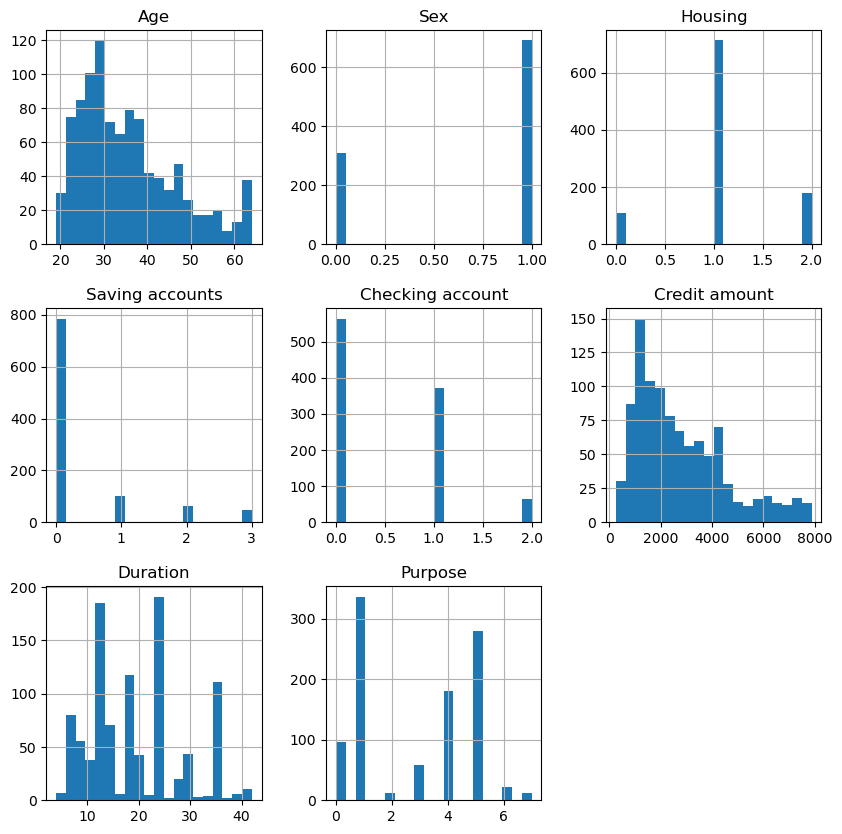

In [22]:
numerical_col = data.select_dtypes(include=['int64', 'float64']).columns
numerical_col = numerical_col.drop(['Unnamed: 0', 'Job'])
data[numerical_col].hist(bins = 20, sharex =False, figsize=(10, 10))
plt.show()

## Standardize the Data

In [23]:
data2 = data.drop(['Unnamed: 0'], axis= 1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data2)

In [24]:
scaled_data = pd.DataFrame(scaled_data,
                          columns= data2.columns.tolist())

In [25]:
data3 = pd.concat([data['Unnamed: 0'], scaled_data], axis = 1)

In [26]:
data3.head(10)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,2.579557,0.670280,0.146949,-0.133710,-0.463409,-0.813780,-0.905136,-1.424063,1.073263
1,1,-1.214175,-1.491914,0.146949,-0.133710,-0.463409,0.817042,1.813427,1.045297,1.073263
2,2,1.224653,0.670280,-1.383771,-0.133710,-0.463409,-0.813780,-0.378138,-0.783020,0.061705
3,3,0.863345,0.670280,0.146949,-2.016956,-0.463409,-0.813780,2.911199,2.422197,0.567484
4,4,1.585961,0.670280,0.146949,-2.016956,-0.463409,-0.813780,1.198879,0.499067,-0.949853
5,5,-0.039925,0.670280,-1.383771,-2.016956,-0.463409,-0.813780,0.750316,1.781154,0.061705
6,6,1.585961,0.670280,0.146949,-0.133710,2.021358,0.817042,0.041983,0.499067,0.567484
7,7,-0.039925,0.670280,1.677670,1.749535,-0.463409,0.817042,2.380220,1.781154,-0.949853
8,8,2.308577,0.670280,-1.383771,-0.133710,3.263742,0.817042,0.169327,-0.783020,1.073263
9,9,-0.672213,0.670280,1.677670,-0.133710,-0.463409,0.817042,1.405813,1.140110,-0.949853


## Modeling

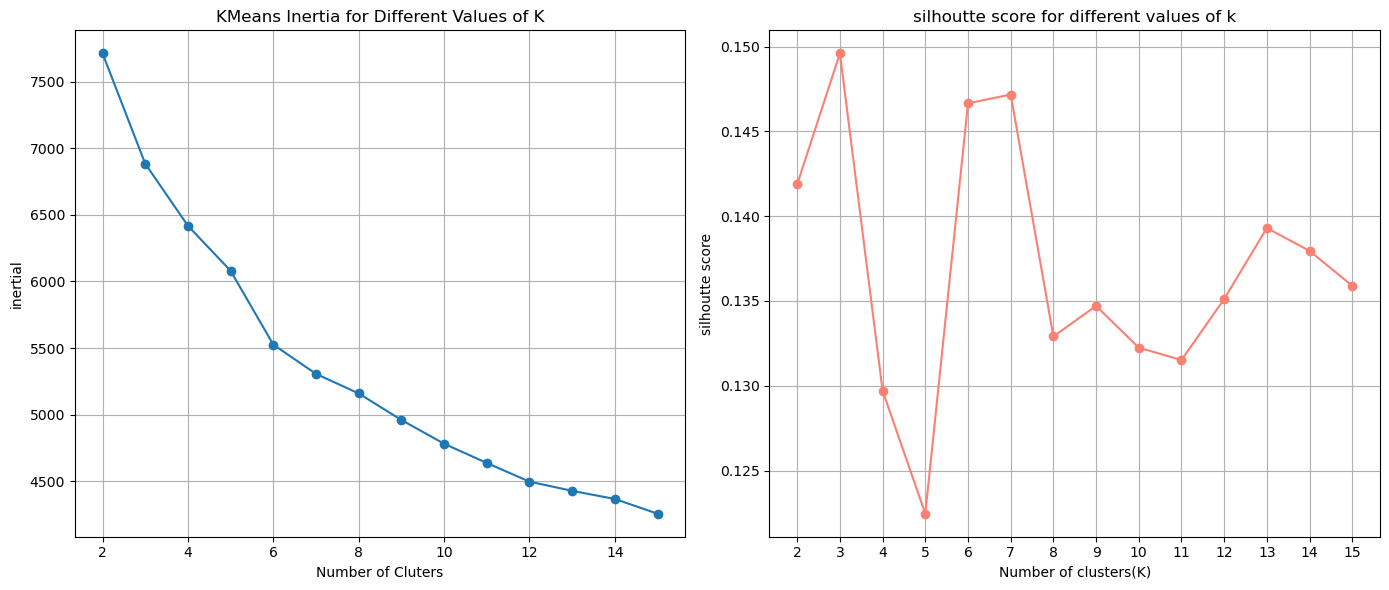

In [28]:
# Using KMeans for Modeling

max_k = 15
inertia = []
silhouette_scores = []

k_vals = range(2, max_k + 1)

for k in k_vals:
    kmeans = KMeans(n_clusters= k , random_state=42, max_iter=1000)
    cluster_label = kmeans.fit_predict(scaled_data)
    sil_score = silhouette_score(scaled_data, cluster_label)
    
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_vals, inertia, marker = 'o')
plt.title('KMeans Inertia for Different Values of K')
plt.xlabel('Number of Cluters')
plt.ylabel('inertial')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_vals, silhouette_scores, marker = 'o', color = 'salmon')
plt.title('silhoutte score for different values of k')
plt.xlabel('Number of clusters(K)')
plt.ylabel('silhoutte score')
plt.xticks(k_vals)
plt.grid(True)

plt.tight_layout()
plt.show()

In [30]:
kmeans = KMeans(n_clusters= 3, 
               random_state=42,
               max_iter=1000)
cluster_label = kmeans.fit_predict(scaled_data)

In [31]:
scaled_data['cluster'] = cluster_label

In [32]:
scaled_data

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,cluster
0,2.579557,0.670280,0.146949,-0.133710,-0.463409,-0.813780,-0.905136,-1.424063,1.073263,1
1,-1.214175,-1.491914,0.146949,-0.133710,-0.463409,0.817042,1.813427,1.045297,1.073263,2
2,1.224653,0.670280,-1.383771,-0.133710,-0.463409,-0.813780,-0.378138,-0.783020,0.061705,1
3,0.863345,0.670280,0.146949,-2.016956,-0.463409,-0.813780,2.911199,2.422197,0.567484,2
4,1.585961,0.670280,0.146949,-2.016956,-0.463409,-0.813780,1.198879,0.499067,-0.949853,2
...,...,...,...,...,...,...,...,...,...,...
995,-0.401232,-1.491914,-1.383771,-0.133710,-0.463409,-0.813780,-0.582797,-0.783020,0.567484,1
996,0.411710,0.670280,1.677670,-0.133710,-0.463409,-0.813780,0.622989,1.140110,-0.949853,2
997,0.231056,0.670280,0.146949,-0.133710,-0.463409,-0.813780,-1.112639,-0.783020,1.073263,1
998,-1.123848,0.670280,0.146949,-2.016956,-0.463409,-0.813780,-0.520831,0.008669,1.073263,1


In [33]:
scaled_data['cluster'].unique()

array([1, 2, 0])

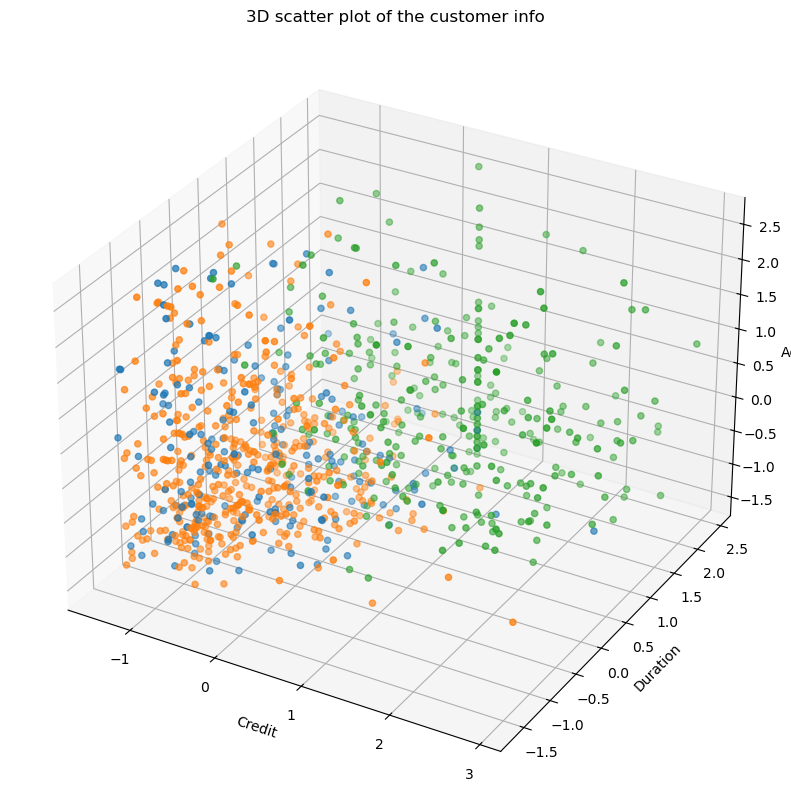

In [39]:
cluster_colors = {
    0:'#1f77b4',
    1:'#ff7f0e',
    2:'#2ca02c' 
}

colors = scaled_data['cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(scaled_data['Credit amount'],
                    scaled_data['Duration'],
                    scaled_data['Age'],
                    c = colors,
                    marker = 'o')

ax.set_xlabel('Credit')
ax.set_ylabel('Duration')
ax.set_zlabel('Age')
ax.set_title('3D scatter plot of the customer info')
plt.show()
